## Notebook 07b - Methodological check: is fragility just centrality concentration?
Núria Pascual Salas

**Content:** Tests whether fragility is simply a reflection of centrality. It checks if teams that become weaker after removing their most central player are also those with a higher concentration of PageRank among their top-N players.

**Inputs:**
- fragility_per_team.csv (PageRank fragility, from notebook 05)
- fragility_per_team_betweenness.csv (betweenness fragility, from notebook 05b)

**Outputs:**
- outputs/csv/centrality_vs_fragility.csv
- outputs/figures/centrality_concentration_vs_fragility.png

**Used in:** Chapter 4 (validation that fragility is not redundant with centrality).

In [1]:
from utils import *
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'

### 1. Build consolidated networks per team and compute PageRank concentration

In [2]:
def concentration_metrics(G):
    """Compute PageRank-based concentration metrics for a network."""
    pr = nx.pagerank(G, weight='weight')
    pr_values = sorted(pr.values(), reverse=True)
    
    return {
        'top1_pr':       pr_values[0] * 100,
        'top3_pr':       sum(pr_values[:3]) * 100,
        'top5_pr':       sum(pr_values[:5]) * 100,
        'pr_std':        np.std(pr_values),
        'pr_gini':       gini_coefficient(pr_values),
        'n_nodes':       G.number_of_nodes(),
    }

In [3]:
# Compute concentration metrics for all teams
concentration_data = []

for team_id, team_name in all_teams.items():
    print(f"Processing {team_name}...")
    G, n_matches = build_consolidated_network(team_id, team_name, zip_path, folder_laliga)
    if G.number_of_nodes() == 0:
        continue
    metrics = concentration_metrics(G)
    metrics['team'] = team_name
    concentration_data.append(metrics)

df_concentration = pd.DataFrame(concentration_data)
print(df_concentration.round(3).to_string(index=False))

Processing Deportivo Alavés...
Processing Granada...
Processing Barcelona...
Processing Almería...
Processing Sevilla...
Processing Cádiz...
Processing Girona...
Processing Athletic Club...
Processing Real Sociedad...
Processing Mallorca...
Processing Real Betis...
Processing Atlético Madrid...
Processing Villarreal...
Processing Celta Vigo...
Processing Valencia...
Processing Las Palmas...
Processing Osasuna...
Processing Real Madrid...
Processing Getafe...
Processing Rayo Vallecano...
 top1_pr  top3_pr  top5_pr  pr_std  pr_gini  n_nodes             team
   9.594   25.001   39.061   0.026    0.413       29 Deportivo Alavés
   8.765   24.478   38.055   0.024    0.494       40          Granada
   9.129   24.660   36.526   0.023    0.375       29        Barcelona
   7.498   20.344   31.869   0.020    0.392       35          Almería
   7.174   20.416   31.827   0.021    0.409       35          Sevilla
   9.791   22.796   34.239   0.023    0.411       33            Cádiz
  11.656   30.316 

### 2. Merge with fragility values

In [4]:
df_frag_pr = pd.read_csv(f'{CSV_DIR}/fragility_per_team.csv')
df_frag_pr = df_frag_pr.rename(columns={'fragility': 'fragility_pagerank'})

df_frag_bt = pd.read_csv(f'{CSV_DIR}/fragility_per_team_betweenness.csv')
df_frag_bt = df_frag_bt.rename(columns={'fragility': 'fragility_betweenness'})

df = df_concentration.merge(df_frag_pr[['team', 'fragility_pagerank']], on='team')
df = df.merge(df_frag_bt[['team', 'fragility_betweenness']], on='team')

df.to_csv(f'{CSV_DIR}/centrality_vs_fragility.csv', index=False)
print(df.round(3).to_string(index=False))

 top1_pr  top3_pr  top5_pr  pr_std  pr_gini  n_nodes             team  fragility_pagerank  fragility_betweenness
   9.594   25.001   39.061   0.026    0.413       29 Deportivo Alavés               0.413                  0.458
   8.765   24.478   38.055   0.024    0.494       40          Granada               0.498                  0.518
   9.129   24.660   36.526   0.023    0.375       29        Barcelona               0.250                  0.283
   7.498   20.344   31.869   0.020    0.392       35          Almería               0.347                  0.323
   7.174   20.416   31.827   0.021    0.409       35          Sevilla               0.297                  0.252
   9.791   22.796   34.239   0.023    0.411       33            Cádiz               0.332                  0.380
  11.656   30.316   45.688   0.032    0.436       25           Girona               0.326                  0.345
   7.109   20.667   33.476   0.021    0.331       27    Athletic Club               0.234       

### 3. Correlations: concentration vs fragility

In [5]:
print("=" * 70)
print("Correlations between PageRank concentration and fragility")
print("=" * 70)
print()

concentration_measures = ['top1_pr', 'top3_pr', 'top5_pr', 'pr_std', 'pr_gini']
fragility_measures     = ['fragility_pagerank', 'fragility_betweenness']

results = []
for cm in concentration_measures:
    for fm in fragility_measures:
        r, p = pearsonr(df[cm], df[fm])
        results.append({
            'concentration_measure': cm,
            'fragility_measure':     fm,
            'r':                     round(r, 3),
            'p_value':               round(p, 4),
        })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

Correlations between PageRank concentration and fragility

concentration_measure     fragility_measure     r  p_value
              top1_pr    fragility_pagerank 0.078   0.7446
              top1_pr fragility_betweenness 0.117   0.6243
              top3_pr    fragility_pagerank 0.086   0.7190
              top3_pr fragility_betweenness 0.132   0.5794
              top5_pr    fragility_pagerank 0.154   0.5156
              top5_pr fragility_betweenness 0.208   0.3783
               pr_std    fragility_pagerank 0.222   0.3466
               pr_std fragility_betweenness 0.243   0.3029
              pr_gini    fragility_pagerank 0.674   0.0011
              pr_gini fragility_betweenness 0.625   0.0032


### 4. Visualisation: top-3 PageRank vs fragility

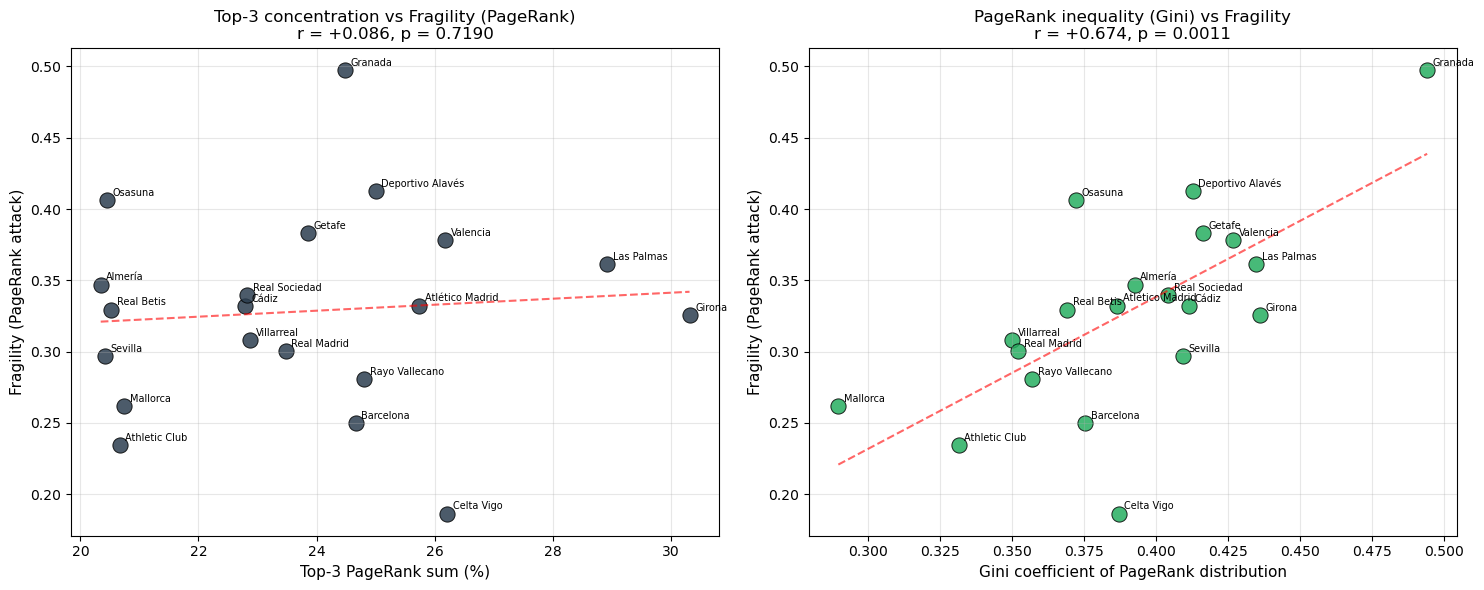

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: top3_pr vs fragility_pagerank
ax = axes[0]
r, p = pearsonr(df['top3_pr'], df['fragility_pagerank'])
ax.scatter(df['top3_pr'], df['fragility_pagerank'], s=120, alpha=0.85,
           color='#2c3e50', edgecolors='black', linewidths=0.7)
for _, row in df.iterrows():
    ax.annotate(row['team'], (row['top3_pr'], row['fragility_pagerank']),
                fontsize=7, textcoords='offset points', xytext=(4, 3))

# Linear fit
m, b = np.polyfit(df['top3_pr'], df['fragility_pagerank'], 1)
x_line = np.linspace(df['top3_pr'].min(), df['top3_pr'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linestyle='--', alpha=0.6)

ax.set_xlabel('Top-3 PageRank sum (%)', fontsize=11)
ax.set_ylabel('Fragility (PageRank attack)', fontsize=11)
ax.set_title(f'Top-3 concentration vs Fragility (PageRank)\nr = {r:+.3f}, p = {p:.4f}',
             fontsize=12)
ax.grid(alpha=0.3)

# Plot 2: gini vs fragility_pagerank
ax = axes[1]
r, p = pearsonr(df['pr_gini'], df['fragility_pagerank'])
ax.scatter(df['pr_gini'], df['fragility_pagerank'], s=120, alpha=0.85,
           color='#27ae60', edgecolors='black', linewidths=0.7)
for _, row in df.iterrows():
    ax.annotate(row['team'], (row['pr_gini'], row['fragility_pagerank']),
                fontsize=7, textcoords='offset points', xytext=(4, 3))

m, b = np.polyfit(df['pr_gini'], df['fragility_pagerank'], 1)
x_line = np.linspace(df['pr_gini'].min(), df['pr_gini'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linestyle='--', alpha=0.6)

ax.set_xlabel('Gini coefficient of PageRank distribution', fontsize=11)
ax.set_ylabel('Fragility (PageRank attack)', fontsize=11)
ax.set_title(f'PageRank inequality (Gini) vs Fragility\nr = {r:+.3f}, p = {p:.4f}',
             fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/centrality_concentration_vs_fragility.png',
            dpi=130, bbox_inches='tight')
plt.show()

### Summary

In [7]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print()
print("Reference table: correlation between each concentration measure and fragility")
print(df_results.to_string(index=False))
print()

main_r = df_results[(df_results['concentration_measure'] == 'top3_pr')
                    & (df_results['fragility_measure'] == 'fragility_pagerank')]
if not main_r.empty:
    r_value = main_r.iloc[0]['r']
    print(f"Main correlation (top-3 PR vs PageRank fragility): r = {r_value:+.3f}")

SUMMARY

Reference table: correlation between each concentration measure and fragility
concentration_measure     fragility_measure     r  p_value
              top1_pr    fragility_pagerank 0.078   0.7446
              top1_pr fragility_betweenness 0.117   0.6243
              top3_pr    fragility_pagerank 0.086   0.7190
              top3_pr fragility_betweenness 0.132   0.5794
              top5_pr    fragility_pagerank 0.154   0.5156
              top5_pr fragility_betweenness 0.208   0.3783
               pr_std    fragility_pagerank 0.222   0.3466
               pr_std fragility_betweenness 0.243   0.3029
              pr_gini    fragility_pagerank 0.674   0.0011
              pr_gini fragility_betweenness 0.625   0.0032

Main correlation (top-3 PR vs PageRank fragility): r = +0.086
